# Real Pose — White Background

Front 2D projection (XY centered on the pelvis) — same reference frame as `kimodo_vs_pipeline_analysis.ipynb`, but with a white background.

In [129]:
%pip install -q numpy matplotlib imageio imageio-ffmpeg ipython

Note: you may need to restart the kernel to use updated packages.


In [130]:
from __future__ import annotations

from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display

np.set_printoptions(precision=4, suppress=True)

In [131]:
# ===== CONFIGURATION =====
ROOT_DIR = Path.cwd().parent

NPZ_PATH = ROOT_DIR / 'output' / 'robot_emotions_pose3d' / '30ms' / 'user_02' / 'robot_emotions_30ms_u02_tag03' / 'pose' / 'pose3d' / 'pose3d.npz'

OUT_DIR   = ROOT_DIR / 'output' / 'pose3d_white_renders'
OUT_VIDEO = OUT_DIR  / 'real_pose_white.mp4'

FRAME_STEP        = 1
MAX_RENDER_FRAMES = 400   # None = render all
PREVIEW_FRAME     = 0

# Figure size and quality
FIGSIZE = (4, 6)   # portrait ratio, as in the reference notebook
DPI     = 128

# Colors — same side palette as the reference notebook
COLOR_LEFT   = '#2196F3'   # blue
COLOR_RIGHT  = '#FF5722'   # orange
COLOR_CENTER = '#4CAF50'   # green
COLOR_DOT    = '#333333'   # dark gray for joints

In [132]:
# Skeleton connectivity — same as reference notebook
SKELETON_EDGES = [
    (0,1),(1,4),(4,7),(7,10),          # left leg
    (0,2),(2,5),(5,8),(8,11),          # right leg
    (0,3),(3,6),(6,9),(9,12),(12,15),  # spine + head
    (13,16),(16,18),(18,20),           # left arm
    (14,17),(17,19),(19,21),           # right arm
    (9,13),(9,14),                     # shoulders
]

JOINT_NAMES = [
    'Pelvis','Left_hip','Right_hip','Spine1','Left_knee','Right_knee',
    'Spine2','Left_ankle','Right_ankle','Spine3','Left_foot','Right_foot',
    'Neck','Left_collar','Right_collar','Head',
    'Left_shoulder','Right_shoulder','Left_elbow','Right_elbow',
    'Left_wrist','Right_wrist',
]

PARENT_INDICES = (
    -1,0,0,0,1,2,3,4,5,6,7,8,9,9,9,12,13,14,16,17,18,19,
)


def bone_color(child_idx):
    name = JOINT_NAMES[child_idx].lower()
    if 'left'  in name: return COLOR_LEFT
    if 'right' in name: return COLOR_RIGHT
    return COLOR_CENTER

In [133]:
def npz_scalar(v):
    return v.item() if isinstance(v, np.ndarray) and v.shape == () else v


def load_pose_sequence(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    d = np.load(path, allow_pickle=True)
    print('Keys:', ', '.join(d.files))

    pos = np.asarray(d['joint_positions_xyz'], dtype=np.float32)  # (T, J, 3)
    fps = float(npz_scalar(d['fps'])) if 'fps' in d else 20.0
    timestamps = (
        np.asarray(d['timestamps_sec'], dtype=np.float32)
        if 'timestamps_sec' in d
        else np.arange(pos.shape[0], dtype=np.float32) / fps
    )
    clip_id = str(npz_scalar(d['clip_id'])) if 'clip_id' in d else path.stem
    print(f'{clip_id}: {pos.shape[0]} frames @ {fps} fps')
    return dict(pos=pos, fps=fps, timestamps=timestamps,
                clip_id=clip_id, num_frames=pos.shape[0])


SEQ = load_pose_sequence(NPZ_PATH)

# Select frames to render
indices = np.arange(0, SEQ['num_frames'], FRAME_STEP, dtype=int)
if MAX_RENDER_FRAMES is not None:
    indices = indices[:MAX_RENDER_FRAMES]

POS       = SEQ['pos'][indices]              # (N, 22, 3)
TIMES     = SEQ['timestamps'][indices]
RENDER_FPS = max(1.0, SEQ['fps'] / max(FRAME_STEP, 1))

# Front projection centered on pelvis — same as reference notebook
POS_CENTERED = POS - POS[:, [0], :]          # pelvis → origin
XS = POS_CENTERED[:, :, 0]                   # lateral
YS = POS_CENTERED[:, :, 1]                   # vertical

# Fixed limits for the entire video
PAD = 0.3
X_LIM = (XS.min() - PAD, XS.max() + PAD)
Y_LIM = (YS.min() - 0.1, YS.max() + PAD)

print(f'Rendering {len(indices)} frames at {RENDER_FPS:.1f} fps')

Keys: clip_id, joint_names_3d, joint_positions_xyz, joint_confidence, observed_mask, imputed_mask, skeleton_parents, frame_indices, timestamps_sec, fps, fps_original, num_frames, num_joints, source, coordinate_space, root_translation_m
robot_emotions_30ms_u02_tag03: 1649 frames @ 20.0 fps
Rendering 400 frames at 20.0 fps


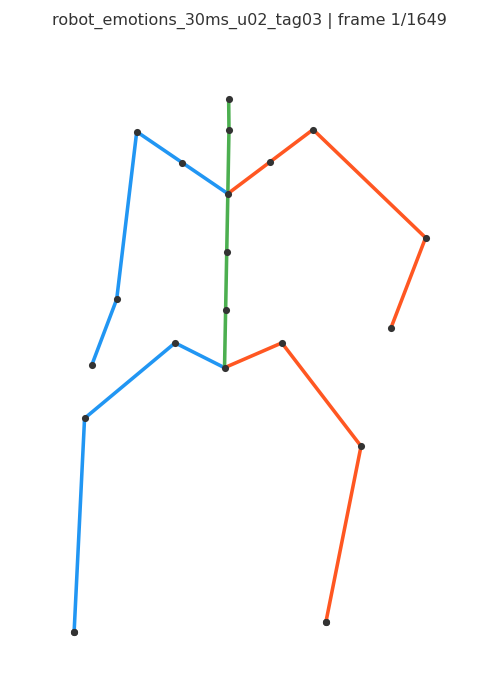

In [134]:
def draw_frame(ax, frame_idx, title=''):
    ax.cla()
    ax.set_facecolor('white')
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_aspect('equal')
    ax.axis('off')
    if title:
        ax.set_title(title, color='#333333', fontsize=9)

    xs_f = XS[frame_idx]
    ys_f = YS[frame_idx]

    for (p, c) in SKELETON_EDGES:
        ax.plot(
            [xs_f[p], xs_f[c]],
            [ys_f[p], ys_f[c]],
            lw=2, color=bone_color(c), solid_capstyle='round',
        )

    ax.plot(xs_f, ys_f, 'o', ms=3, color=COLOR_DOT, zorder=5)


# Preview
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, facecolor='white')
draw_frame(ax, int(np.clip(PREVIEW_FRAME, 0, len(indices)-1)),
           title=f"{SEQ['clip_id']} | frame {int(indices[PREVIEW_FRAME])+1}/{SEQ['num_frames']}")
plt.tight_layout()
plt.show()

In [135]:
def figure_to_rgb(fig):
    fig.canvas.draw()
    return np.array(np.asarray(fig.canvas.buffer_rgba())[..., :3], copy=True)


def render_video(output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, facecolor='white')

    with imageio.get_writer(
        output_path, fps=RENDER_FPS,
        codec='libx264', quality=7, ffmpeg_log_level='error',
    ) as writer:
        for i in range(len(indices)):
            draw_frame(
                ax, i,
                title=(
                    f"{SEQ['clip_id']} | "
                    f"frame {int(indices[i])+1}/{SEQ['num_frames']} | "
                    f"t={TIMES[i]:.2f}s"
                ),
            )
            writer.append_data(figure_to_rgb(fig))

            if (i + 1) % 20 == 0 or (i + 1) == len(indices):
                print(f'Rendered: {i+1}/{len(indices)}')

    plt.close(fig)
    return output_path


rendered = render_video(OUT_VIDEO)
print(f'Video saved at: {rendered}')

Rendered: 20/400
Rendered: 40/400
Rendered: 60/400
Rendered: 80/400
Rendered: 100/400
Rendered: 120/400
Rendered: 140/400
Rendered: 160/400
Rendered: 180/400
Rendered: 200/400
Rendered: 220/400
Rendered: 240/400
Rendered: 260/400
Rendered: 280/400
Rendered: 300/400
Rendered: 320/400
Rendered: 340/400
Rendered: 360/400
Rendered: 380/400
Rendered: 400/400
Video saved at: /home/henriquesouza/POSE2IMU-Framework/output/pose3d_white_renders/real_pose_white.mp4


In [136]:
display(Video(str(rendered), embed=True))

---
## Version with axes

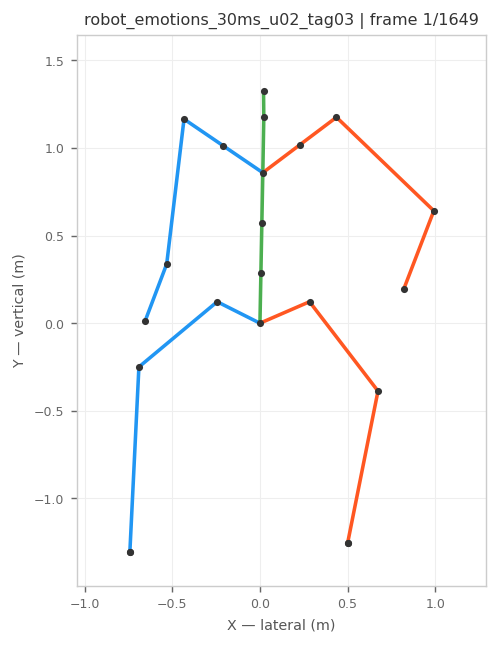

In [137]:
def draw_frame_axes(ax, frame_idx, title=''):
    ax.cla()
    ax.set_facecolor('white')
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_aspect('equal')
    ax.set_xlabel('X — lateral (m)', color='#555555', fontsize=8)
    ax.set_ylabel('Y — vertical (m)', color='#555555', fontsize=8)
    ax.tick_params(colors='#666666', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.grid(True, color='#eeeeee', linewidth=0.6, zorder=0)
    if title:
        ax.set_title(title, color='#333333', fontsize=9)

    xs_f = XS[frame_idx]
    ys_f = YS[frame_idx]

    for (p, c) in SKELETON_EDGES:
        ax.plot(
            [xs_f[p], xs_f[c]],
            [ys_f[p], ys_f[c]],
            lw=2, color=bone_color(c), solid_capstyle='round', zorder=3,
        )

    ax.plot(xs_f, ys_f, 'o', ms=3, color=COLOR_DOT, zorder=5)


# Preview com eixos
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, facecolor='white')
draw_frame_axes(
    ax, int(np.clip(PREVIEW_FRAME, 0, len(indices)-1)),
    title=f"{SEQ['clip_id']} | frame {int(indices[PREVIEW_FRAME])+1}/{SEQ['num_frames']}",
)
plt.tight_layout()
plt.show()

In [138]:
OUT_VIDEO_AXES = OUT_DIR / 'real_pose_white_axes.mp4'

def render_video_axes(output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI, facecolor='white')

    with imageio.get_writer(
        output_path, fps=RENDER_FPS,
        codec='libx264', quality=7, ffmpeg_log_level='error',
    ) as writer:
        for i in range(len(indices)):
            draw_frame_axes(
                ax, i,
                title=(
                    f"{SEQ['clip_id']} | "
                    f"frame {int(indices[i])+1}/{SEQ['num_frames']} | "
                    f"t={TIMES[i]:.2f}s"
                ),
            )
            writer.append_data(figure_to_rgb(fig))

            if (i + 1) % 20 == 0 or (i + 1) == len(indices):
                print(f'Rendered: {i+1}/{len(indices)}')

    plt.close(fig)
    return output_path


rendered_axes = render_video_axes(OUT_VIDEO_AXES)
print(f'Video with axes saved at: {rendered_axes}')

Rendered: 20/400
Rendered: 40/400
Rendered: 60/400
Rendered: 80/400
Rendered: 100/400
Rendered: 120/400
Rendered: 140/400
Rendered: 160/400
Rendered: 180/400
Rendered: 200/400
Rendered: 220/400
Rendered: 240/400
Rendered: 260/400
Rendered: 280/400
Rendered: 300/400
Rendered: 320/400
Rendered: 340/400
Rendered: 360/400
Rendered: 380/400
Rendered: 400/400
Video with axes saved at: /home/henriquesouza/POSE2IMU-Framework/output/pose3d_white_renders/real_pose_white_axes.mp4


In [139]:
display(Video(str(rendered_axes), embed=True))

---
## 3D Version (Axes3D)

Matplotlib axes remapped so that the data Y axis (vertical) corresponds to matplotlib's Z axis (up).
Default front view — rotate interactively in Jupyter.

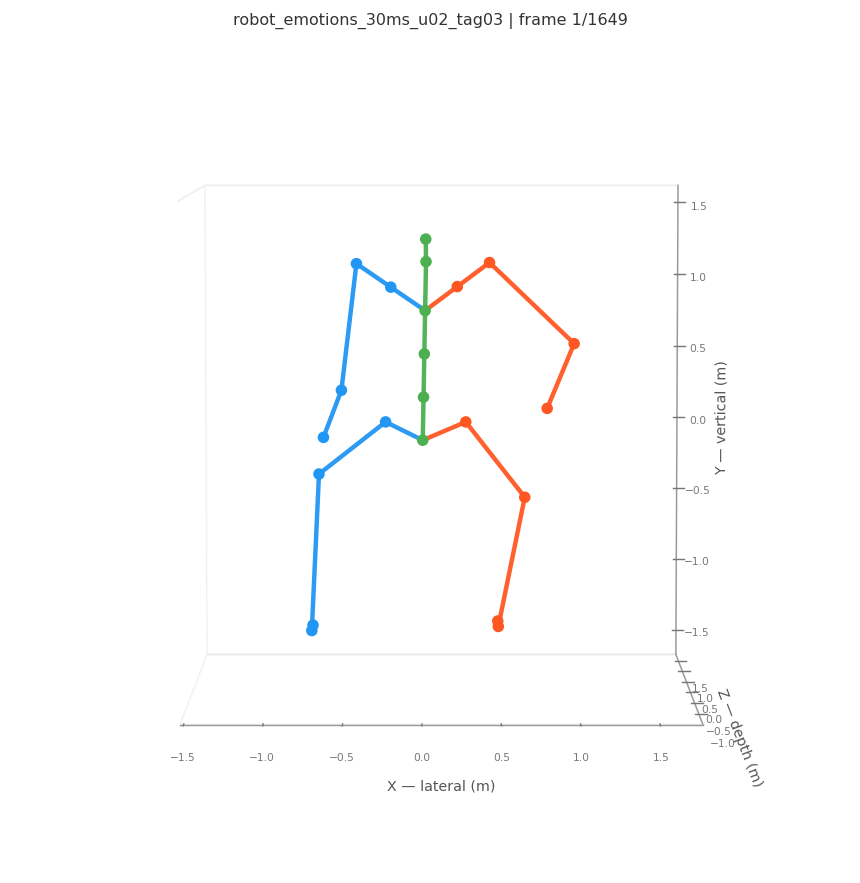

In [140]:
# 3D camera parameters
VIEW_ELEV_3D = 5   # nearly frontal; adjust to rotate
VIEW_AZIM_3D = -90  # looking from the front (along data Z axis)
FIGSIZE_3D   = (7, 7)

# Hip-centered data (same used in 2D versions)
# Remapping: matplotlib(x, y, z) = data(X_lateral, Z_depth, Y_vertical)
# So matplotlib Z axis (up) = data Y axis (vertical).
POS_3D = POS_CENTERED                   # (N, 22, 3)  hip-centered
M_X = POS_3D[:, :, 0]                  # lateral
M_Y = POS_3D[:, :, 2]                  # depth → matplotlib Y axis
M_Z = POS_3D[:, :, 1]                  # vertical → matplotlib Z axis (up)

# Cubic limits
_flat = POS_3D.reshape(-1, 3)
_mins, _maxs = _flat.min(0), _flat.max(0)
_center = (_mins + _maxs) / 2
_half   = max(float((_maxs - _mins).max()), 0.8) * 0.6
LIMITS_3D = (
    (float(_center[0] - _half), float(_center[0] + _half)),   # X lateral
    (float(_center[2] - _half), float(_center[2] + _half)),   # Z depth
    (float(_center[1] - _half), float(_center[1] + _half)),   # Y vertical
)


def _style_3d_white(ax):
    ax.set_facecolor('white')
    ax.figure.patch.set_facecolor('white')
    for axis_name in ('xaxis', 'yaxis', 'zaxis'):
        axis = getattr(ax, axis_name)
        axis.pane.set_facecolor((1.0, 1.0, 1.0, 1.0))
        axis.pane.set_edgecolor((0.88, 0.88, 0.88, 1.0))
        axis.line.set_color((0.6, 0.6, 0.6))
    ax.grid(False)


def draw_frame_3d(ax, frame_idx, title=''):
    ax.cla()
    _style_3d_white(ax)

    mx = M_X[frame_idx]
    my = M_Y[frame_idx]
    mz = M_Z[frame_idx]

    for (p, c) in SKELETON_EDGES:
        ax.plot(
            [mx[p], mx[c]], [my[p], my[c]], [mz[p], mz[c]],
            lw=2.5, color=bone_color(c), alpha=0.95, solid_capstyle='round',
        )

    ax.scatter(mx, my, mz,
               c=[bone_color(i) for i in range(len(JOINT_NAMES))],
               s=30, depthshade=False, zorder=5)

    (x0, x1), (y0, y1), (z0, z1) = LIMITS_3D
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_zlim(z0, z1)
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect((x1-x0, y1-y0, z1-z0))

    ax.set_xlabel('X — lateral (m)', color='#555', fontsize=8, labelpad=4)
    ax.set_ylabel('Z — depth (m)',   color='#555', fontsize=8, labelpad=4)
    ax.set_zlabel('Y — vertical (m)',color='#555', fontsize=8, labelpad=4)
    ax.tick_params(colors='#777', labelsize=6)
    ax.view_init(elev=VIEW_ELEV_3D, azim=VIEW_AZIM_3D)
    if title:
        ax.set_title(title, color='#333', fontsize=9)


# Preview
fig = plt.figure(figsize=FIGSIZE_3D, dpi=DPI, facecolor='white')
ax  = fig.add_subplot(111, projection='3d')
draw_frame_3d(
    ax, int(np.clip(PREVIEW_FRAME, 0, len(indices)-1)),
    title=f"{SEQ['clip_id']} | frame {int(indices[PREVIEW_FRAME])+1}/{SEQ['num_frames']}",
)
plt.tight_layout()
plt.show()

### Interactive camera adjustment

In [141]:
import ipywidgets as widgets
from ipywidgets import interact, IntSlider
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')


def _style_3d_visible(ax):
    ax.set_facecolor('white')
    ax.figure.patch.set_facecolor('white')
    for axis_name in ('xaxis', 'yaxis', 'zaxis'):
        axis = getattr(ax, axis_name)
        axis.pane.set_facecolor((0.96, 0.96, 0.96, 1.0))   # soft gray on planes
        axis.pane.set_edgecolor((0.4, 0.4, 0.4, 1.0))      # dark border
        axis.line.set_color((0.2, 0.2, 0.2))                # dark axis line
    ax.grid(True, color='#aaaaaa', linewidth=0.7)


def _draw_3d(frame_idx, elev, azim):
    fig = plt.figure(figsize=FIGSIZE_3D, dpi=80, facecolor='white')
    ax  = fig.add_subplot(111, projection='3d')
    _style_3d_visible(ax)

    mx = M_X[frame_idx]
    my = M_Y[frame_idx]
    mz = M_Z[frame_idx]

    for (p, c) in SKELETON_EDGES:
        ax.plot(
            [mx[p], mx[c]], [my[p], my[c]], [mz[p], mz[c]],
            lw=2.5, color=bone_color(c), alpha=0.95, solid_capstyle='round',
        )
    ax.scatter(mx, my, mz,
               c=[bone_color(i) for i in range(len(JOINT_NAMES))],
               s=30, depthshade=False, zorder=5)

    (x0, x1), (y0, y1), (z0, z1) = LIMITS_3D
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_zlim(z0, z1)
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect((x1-x0, y1-y0, z1-z0))

    ax.set_xlabel('X — lateral (m)',  color='#222', fontsize=8, labelpad=6)
    ax.set_ylabel('Z — depth (m)',    color='#222', fontsize=8, labelpad=6)
    ax.set_zlabel('Y — vertical (m)', color='#222', fontsize=8, labelpad=6)
    ax.tick_params(colors='#222', labelsize=7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(
        f"{SEQ['clip_id']} | frame {int(indices[frame_idx])+1}/{SEQ['num_frames']} | "
        f"elev={elev}° azim={azim}°",
        color='#111', fontsize=9,
    )
    plt.tight_layout()
    plt.show()


interact(
    _draw_3d,
    frame_idx=IntSlider(min=0, max=len(indices)-1, step=1,  value=0,   description='Frame',   continuous_update=False),
    elev     =IntSlider(min=-90, max=90,           step=5,  value=5,   description='Elev (°)', continuous_update=False),
    azim     =IntSlider(min=-180, max=180,         step=5,  value=-90, description='Azim (°)', continuous_update=False),
);

interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=399), IntSlider(val…

In [142]:
OUT_VIDEO_3D = OUT_DIR / 'real_pose_white_3d.mp4'

def render_video_3d(output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=FIGSIZE_3D, dpi=DPI, facecolor='white')
    ax  = fig.add_subplot(111, projection='3d')

    with imageio.get_writer(
        output_path, fps=RENDER_FPS,
        codec='libx264', quality=7, ffmpeg_log_level='error',
    ) as writer:
        for i in range(len(indices)):
            draw_frame_3d(
                ax, i,
                title=(
                    f"{SEQ['clip_id']} | "
                    f"frame {int(indices[i])+1}/{SEQ['num_frames']} | "
                    f"t={TIMES[i]:.2f}s"
                ),
            )
            writer.append_data(figure_to_rgb(fig))

            if (i + 1) % 20 == 0 or (i + 1) == len(indices):
                print(f'Rendered: {i+1}/{len(indices)}')

    plt.close(fig)
    return output_path


rendered_3d = render_video_3d(OUT_VIDEO_3D)
print(f'3D video saved at: {rendered_3d}')

Rendered: 20/400
Rendered: 40/400
Rendered: 60/400
Rendered: 80/400
Rendered: 100/400
Rendered: 120/400
Rendered: 140/400
Rendered: 160/400
Rendered: 180/400
Rendered: 200/400
Rendered: 220/400
Rendered: 240/400
Rendered: 260/400
Rendered: 280/400
Rendered: 300/400
Rendered: 320/400
Rendered: 340/400
Rendered: 360/400
Rendered: 380/400
Rendered: 400/400
3D video saved at: /home/henriquesouza/POSE2IMU-Framework/output/pose3d_white_renders/real_pose_white_3d.mp4


In [143]:
display(Video(str(rendered_3d), embed=True))

---
## Export PNG — transparent background

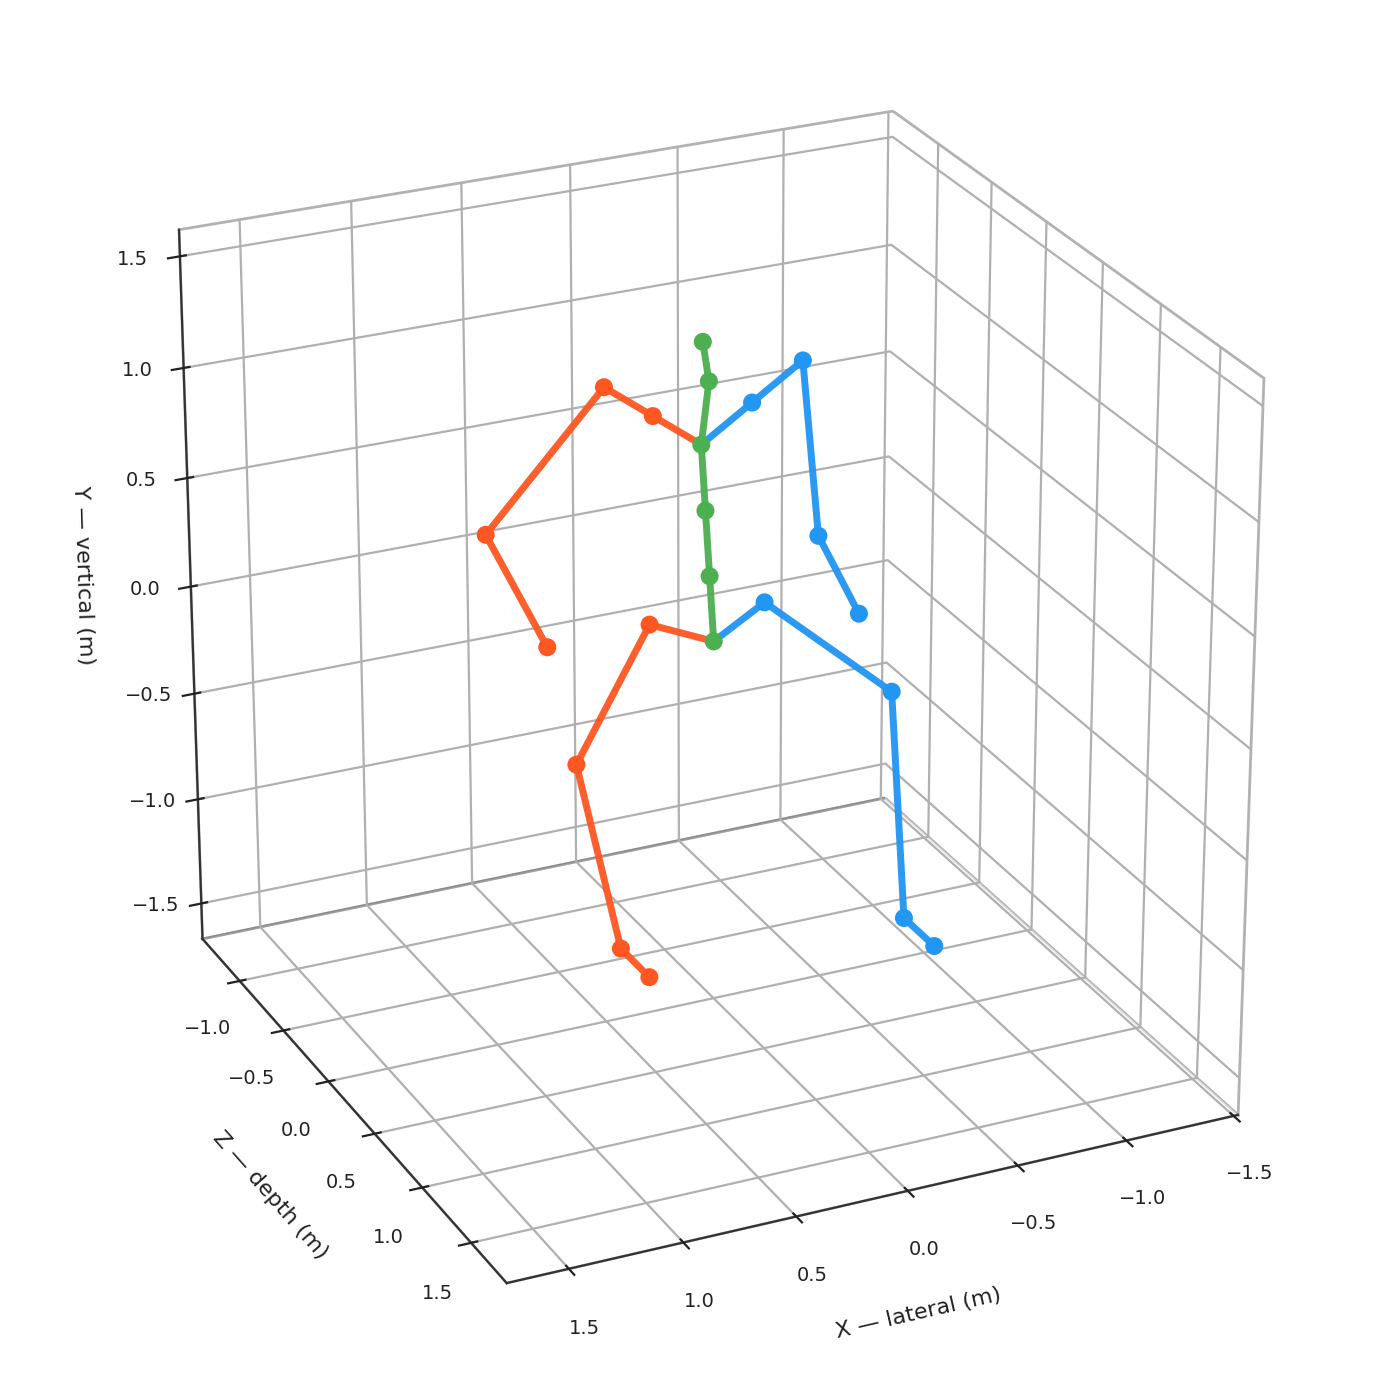

Saved at: /home/henriquesouza/POSE2IMU-Framework/output/pose3d_white_renders/pose3d_transparent.png


In [144]:
# ===== EXPORT PARAMETERS =====
EXPORT_FRAME = 0      # index within `indices` (not the original frame)
EXPORT_ELEV  = 25      # degrees
EXPORT_AZIM  = 65    # degrees
EXPORT_DPI   = 200
EXPORT_PATH  = OUT_DIR / 'pose3d_transparent.png'
# ================================

def export_3d_transparent(frame_idx, elev, azim, out_path, dpi=200):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=FIGSIZE_3D, dpi=dpi, facecolor='none')
    ax  = fig.add_subplot(111, projection='3d')

    # Planes: transparent fill, visible border and grid
    for axis_name in ('xaxis', 'yaxis', 'zaxis'):
        axis = getattr(ax, axis_name)
        axis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))   # transparent
        axis.pane.set_edgecolor((0.4, 0.4, 0.4, 1.0))
        axis.line.set_color((0.2, 0.2, 0.2))
    ax.set_facecolor((0, 0, 0, 0))
    ax.grid(True, color='#aaaaaa', linewidth=0.7)

    mx = M_X[frame_idx]
    my = M_Y[frame_idx]
    mz = M_Z[frame_idx]

    for (p, c) in SKELETON_EDGES:
        ax.plot(
            [mx[p], mx[c]], [my[p], my[c]], [mz[p], mz[c]],
            lw=2.5, color=bone_color(c), alpha=0.95, solid_capstyle='round',
        )
    ax.scatter(mx, my, mz,
               c=[bone_color(i) for i in range(len(JOINT_NAMES))],
               s=30, depthshade=False, zorder=5)

    (x0, x1), (y0, y1), (z0, z1) = LIMITS_3D
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_zlim(z0, z1)
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect((x1-x0, y1-y0, z1-z0))

    ax.set_xlabel('X — lateral (m)',  color='#222', fontsize=8, labelpad=6)
    ax.set_ylabel('Z — depth (m)',    color='#222', fontsize=8, labelpad=6)
    ax.set_zlabel('Y — vertical (m)', color='#222', fontsize=8, labelpad=6)
    ax.tick_params(colors='#222', labelsize=7)
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    fig.savefig(out_path, dpi=dpi, transparent=True, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved at: {out_path}')


export_3d_transparent(EXPORT_FRAME, EXPORT_ELEV, EXPORT_AZIM, EXPORT_PATH, dpi=EXPORT_DPI)

Video: /home/henriquesouza/POSE2IMU-Framework/data/RobotEmotions/30ms/User2/Tag3/TAG_3.mp4
Timestamp: 0.000s  →  original frame #0  (fps_orig=20.0)
Saved at: /home/henriquesouza/POSE2IMU-Framework/output/pose3d_white_renders/video_frame_0.png


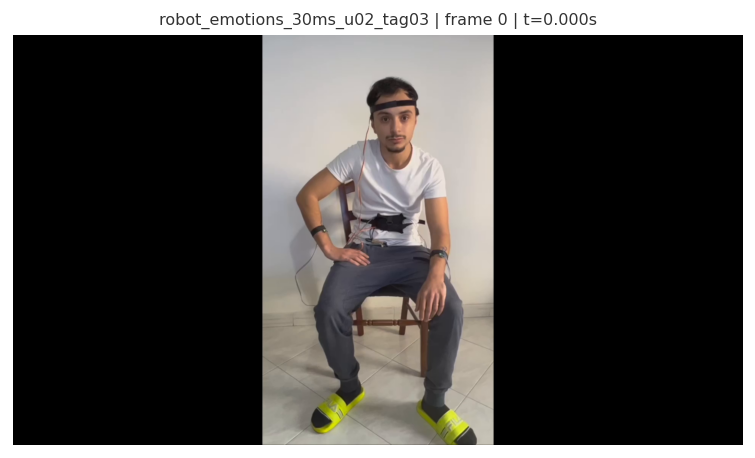

In [145]:
import glob, re

# Parse user and tag numbers from clip_id (e.g. 'robot_emotions_30ms_u02_tag03')
clip_id = SEQ['clip_id']
domain  = NPZ_PATH.parts[-6]   # e.g. '30ms'
m = re.search(r'_u(\d+)_tag(\d+)', clip_id)
user_no, tag_no = int(m.group(1)), int(m.group(2))
video_path = (ROOT_DIR / 'data' / 'RobotEmotions' / domain
              / f'User{user_no}' / f'Tag{tag_no}' / f'TAG_{tag_no}.mp4')
print(f'Video: {video_path}')

# Compute the frame number in the original video
t = float(TIMES[EXPORT_FRAME])
fps_orig = float(SEQ.get('fps_original', SEQ['fps']))
orig_frame_no = int(round(t * fps_orig))
print(f'Timestamp: {t:.3f}s  →  original frame #{orig_frame_no}  (fps_orig={fps_orig})')

# Extract and display the frame
with imageio.get_reader(str(video_path)) as reader:
    video_frame = reader.get_data(orig_frame_no)

fig, ax = plt.subplots(figsize=(6, 4), dpi=DPI, facecolor='white')
ax.imshow(video_frame)
ax.axis('off')
ax.set_title(f'{clip_id} | frame {orig_frame_no} | t={t:.3f}s', fontsize=9, color='#333')
plt.tight_layout()

out_frame_path = OUT_DIR / f'video_frame_{orig_frame_no}.png'
fig.savefig(out_frame_path, dpi=EXPORT_DPI, bbox_inches='tight')
print(f'Saved at: {out_frame_path}')
plt.show()